1. Imports & configuration
2. Load processed datasets
3. Load locked experiment split
4. Verify split integrity
5. Prepare X / y for each model
6. Train 4 Isolation Forest models
7. Validation predictions
8. Select F1 thresholds
9. Freeze models + thresholds
10. Final-test predictions
11. Calculate evaluation metrics
12. Compare Models 1–4
13. Confusion matrices / diagnostic plots
14. Save models, thresholds and results

## 0.&nbsp;Data Loading and Preparation, Train-Validation-Test-split

In [2]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)


# ============================================================
# Configuration
# ============================================================

RANDOM_STATE = 42
N_ESTIMATORS = 300
MAX_MISSING_FRACTION = 0.95


# ============================================================
# Paths
# ============================================================

BASELINE_RAW_WINDOWS_PATH = (
    "../data/processed/baseline_raw_windows.parquet"
)

WINDOW_FEATURES_PATH = (
    "../data/processed/window_features.parquet"
)

TEMPORAL_FEATURES_PATH = (
    "../data/processed/temporal_features.parquet"
)

ML_FEATURES_PATH = (
    "../data/processed/ml_features.parquet"
)

EXPERIMENT_SPLIT_PATH = (
    "../data/processed/experiment_split.parquet"
)


# ============================================================
# Load datasets
# ============================================================

baseline_raw_windows = pd.read_parquet(
    BASELINE_RAW_WINDOWS_PATH
)

window_features = pd.read_parquet(
    WINDOW_FEATURES_PATH
)

temporal_features = pd.read_parquet(
    TEMPORAL_FEATURES_PATH
)

ml_features = pd.read_parquet(
    ML_FEATURES_PATH
)

experiment_split = pd.read_parquet(
    EXPERIMENT_SPLIT_PATH
)


# ============================================================
# Dataset collection
# ============================================================

datasets = {
    "baseline_raw_windows": baseline_raw_windows,
    "window_features": window_features,
    "temporal_features": temporal_features,
    "ml_features": ml_features,
}


# ============================================================
# Locked experiment split
# ============================================================

def assign_model_split(df, experiment_split):
    """
    Assign the locked experiment-level split.

    train:
        all train_normal experiments

    validation / final_test:
        assignments from experiment_split

    unassigned:
        remain excluded from ML
    """

    df = df.copy()

    if experiment_split["identifier"].duplicated().any():
        raise ValueError(
            "Duplicate identifiers found in experiment_split."
        )

    df["model_split"] = pd.Series(
        pd.NA,
        index=df.index,
        dtype="string",
    )

    # Training = normal experiments
    train_mask = (
        df["experiment_type"] == "train_normal"
    )

    df.loc[
        train_mask,
        "model_split"
    ] = "train"

    # Validation / final test
    split_mapping = (
        experiment_split
        .set_index("identifier")["split"]
    )

    mapped_split = df["identifier"].map(
        split_mapping
    )

    mapped_mask = mapped_split.notna()

    df.loc[
        mapped_mask,
        "model_split"
    ] = mapped_split.loc[mapped_mask].astype("string")

    return df


for name in datasets:
    datasets[name] = assign_model_split(
        datasets[name],
        experiment_split,
    )


# ============================================================
# Observable anomaly target
# ============================================================

def add_observable_anomaly_target(df):
    """
    Convert anomaly_label into the binary observable anomaly target.

    anomaly_label:
        0 = normal
        1 = blind phase -> excluded
        2 = observable anomaly
        3 = observable after-effect

    observable_anomaly:
        0 = normal
        1 = observable anomaly
        NaN = excluded
    """

    df = df.copy()

    if "anomaly_label" not in df.columns:
        raise ValueError(
            "'anomaly_label' column not found."
        )

    df["observable_anomaly"] = np.nan

    df.loc[
        df["anomaly_label"] == 0,
        "observable_anomaly"
    ] = 0

    df.loc[
        df["anomaly_label"].isin([2, 3]),
        "observable_anomaly"
    ] = 1

    return df


for name in datasets:
    datasets[name] = add_observable_anomaly_target(
        datasets[name]
    )


# ============================================================
# Update named datasets
# ============================================================

baseline_raw_windows = datasets["baseline_raw_windows"]
window_features = datasets["window_features"]
temporal_features = datasets["temporal_features"]
ml_features = datasets["ml_features"]


# ============================================================
# Feature definitions
# ============================================================

metadata_columns = [
    "identifier",
    "phase",
    "batch",
    "operating_point",
    "experiment",
    "experiment_type",
    "window",
    "window_start",
    "window_end",
    "anomaly_label",
    "observable_anomaly",
    "model_split",
]


EXPECTED_FEATURE_COUNTS = {
    "baseline_raw_windows": 1800,
    "window_features": 240,
    "temporal_features": 720,
    "ml_features": 780,
}


def get_feature_columns(df):
    """Return ML feature columns only."""

    return [
        column
        for column in df.columns
        if column not in metadata_columns
    ]


# ============================================================
# Create model datasets
# ============================================================

def create_model_datasets(df):
    """
    Create train, validation and final-test datasets.

    Windows with no model_split or no observable_anomaly
    remain excluded.
    """

    train = df[
        (df["model_split"] == "train")
        & (df["observable_anomaly"] == 0)
    ].copy()

    validation = df[
        df["model_split"] == "validation"
    ].copy()

    final_test = df[
        df["model_split"] == "final_test"
    ].copy()

    # Remove blind-phase windows from evaluation
    validation = validation[
        validation["observable_anomaly"].notna()
    ].copy()

    final_test = final_test[
        final_test["observable_anomaly"].notna()
    ].copy()

    return train, validation, final_test


model_datasets = {}

for name, df in datasets.items():

    train, validation, final_test = (
        create_model_datasets(df)
    )

    model_datasets[name] = {
        "train": train,
        "validation": validation,
        "final_test": final_test,
    }


# ============================================================
# Essential validation
# ============================================================

summary_rows = []

for name, df in datasets.items():

    feature_columns = get_feature_columns(df)

    expected_features = EXPECTED_FEATURE_COUNTS[name]

    if len(feature_columns) != expected_features:
        raise ValueError(
            f"{name}: expected {expected_features} features, "
            f"found {len(feature_columns)}."
        )

    # Check infinite values
    numeric_features = df[
        feature_columns
    ].select_dtypes(include=np.number)

    n_inf = np.isinf(
        numeric_features
    ).sum().sum()

    if n_inf > 0:
        raise ValueError(
            f"{name}: {n_inf:,} infinite values found."
        )

    # Missing-feature fraction
    missing_fraction = (
        df[feature_columns]
        .isna()
        .mean()
    )

    n_high_missing = (
        missing_fraction > MAX_MISSING_FRACTION
    ).sum()

    split_counts = (
        df["model_split"]
        .value_counts(dropna=False)
    )

    summary_rows.append({
        "dataset": name,
        "windows": len(df),
        "features": len(feature_columns),
        "train": split_counts.get("train", 0),
        "validation": split_counts.get("validation", 0),
        "final_test": split_counts.get("final_test", 0),
        "excluded": df["model_split"].isna().sum(),
        "high_missing_features": n_high_missing,
    })


summary = pd.DataFrame(summary_rows)


# ============================================================
# Final data summary
# ============================================================

print("=" * 70)
print("ML DATASET SUMMARY")
print("=" * 70)

display(summary)

print(
    f"\nExcluded windows: "
    f"{summary['excluded'].iloc[0]}"
)

print(
    "\nPrimary metric: AUPRC"
    "\nSecondary metric: F1"
)

print("\n✓ Data preparation complete.")

ML DATASET SUMMARY


,dataset,windows,features,train,validation,final_test,excluded,high_missing_features
0,baseline_raw_windows,11512,1800,3738,3670,3901,203,0
1,window_features,11512,240,3738,3670,3901,203,0
2,temporal_features,11512,720,3738,3670,3901,203,0
3,ml_features,11512,780,3738,3670,3901,203,2



Excluded windows: 203

Primary metric: AUPRC
Secondary metric: F1

✓ Data preparation complete.


## 1.&nbsp;Baseline Isolation Forest Evaluation

In [3]:
# ============================================================
# Baseline Isolation Forest Evaluation
# ============================================================

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


# ============================================================
# Configuration
# ============================================================

RANDOM_STATE = 42
N_ESTIMATORS = 300
MAX_MISSING_FRACTION = 0.95


# ============================================================
# Feature sets
# ============================================================

MODEL_FEATURE_SETS = {
    "baseline_raw_windows": baseline_raw_windows,
    "window_features": window_features,
    "temporal_features": temporal_features,
    "ml_features": ml_features,
}


# ============================================================
# Metadata columns
# ============================================================

# These columns are NOT used as ML features.
#
# They are retained only for:
# - experiment identification
# - train/validation/final-test splitting
# - anomaly labels
# - traceability
#
# Therefore, no metadata is passed to the Isolation Forest.

metadata_columns = [
    "identifier",
    "phase",
    "batch",
    "operating_point",
    "experiment",
    "experiment_type",
    "window",
    "window_start",
    "window_end",
    "anomaly_label",
    "observable_anomaly",
    "model_split",
]


# ============================================================
# Expected feature counts
# ============================================================

EXPECTED_FEATURE_COUNTS = {
    "baseline_raw_windows": 1800,
    "window_features": 240,
    "temporal_features": 720,
    "ml_features": 780,
}


# ============================================================
# Helper: identify ML features
# ============================================================

def get_feature_columns(df):
    """
    Return only actual ML feature columns.

    Metadata and target/split columns are excluded.
    """

    return [
        column
        for column in df.columns
        if column not in metadata_columns
    ]


# ============================================================
# Helper: prepare train and validation features
# ============================================================

def prepare_features(train_df, validation_df):
    """
    Prepare feature matrices for Isolation Forest.

    Steps:
    1. Identify ML features.
    2. Remove features with >95% missing values in TRAINING data.
    3. Fit median imputer on TRAINING data only.
    4. Apply the same imputer to validation data.

    This prevents information leakage from validation into training.
    """

    feature_columns = get_feature_columns(train_df)

    # --------------------------------------------------------
    # Check expected feature count
    # --------------------------------------------------------

    dataset_name = None

    for name, df in MODEL_FEATURE_SETS.items():
        if df is train_df:
            dataset_name = name
            break

    if dataset_name is not None:

        expected_count = EXPECTED_FEATURE_COUNTS[
            dataset_name
        ]

        if len(feature_columns) != expected_count:
            raise ValueError(
                f"{dataset_name}: expected "
                f"{expected_count} original features, "
                f"found {len(feature_columns)}."
            )

    # --------------------------------------------------------
    # Check for infinite values
    # --------------------------------------------------------

    train_numeric = train_df[
        feature_columns
    ].select_dtypes(include=np.number)

    validation_numeric = validation_df[
        feature_columns
    ].select_dtypes(include=np.number)

    train_inf = np.isinf(
        train_numeric
    ).sum().sum()

    validation_inf = np.isinf(
        validation_numeric
    ).sum().sum()

    if train_inf > 0:
        raise ValueError(
            f"Training data contains "
            f"{train_inf:,} infinite values."
        )

    if validation_inf > 0:
        raise ValueError(
            f"Validation data contains "
            f"{validation_inf:,} infinite values."
        )

    # --------------------------------------------------------
    # Remove features with excessive missingness
    #
    # IMPORTANT:
    # The threshold is calculated using TRAINING data only.
    # --------------------------------------------------------

    missing_fraction = (
        train_df[feature_columns]
        .isna()
        .mean()
    )

    features_to_remove = (
        missing_fraction
        > MAX_MISSING_FRACTION
    )

    features_used = (
        missing_fraction[
            ~features_to_remove
        ]
        .index
        .tolist()
    )

    if len(features_used) == 0:
        raise ValueError(
            "No features remain after missing-value filtering."
        )

    # --------------------------------------------------------
    # Create matrices
    # --------------------------------------------------------

    X_train_raw = train_df[
        features_used
    ]

    X_validation_raw = validation_df[
        features_used
    ]

    # --------------------------------------------------------
    # Median imputation
    #
    # Fit ONLY on training data.
    # --------------------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train = imputer.fit_transform(
        X_train_raw
    )

    X_validation = imputer.transform(
        X_validation_raw
    )

    return (
        X_train,
        X_validation,
        features_used,
        imputer,
    )


# ============================================================
# Train and evaluate baseline models
# ============================================================

results = []

trained_models = {}

preprocessors = {}

used_features = {}


for model_name, df in MODEL_FEATURE_SETS.items():

    print(
        f"Running: {model_name}"
    )

    # --------------------------------------------------------
    # Create train / validation / final-test datasets
    # --------------------------------------------------------

    train_df = df[
        (df["model_split"] == "train")
        & (df["observable_anomaly"] == 0)
    ].copy()

    validation_df = df[
        df["model_split"] == "validation"
    ].copy()

    # Remove blind-phase windows
    validation_df = validation_df[
        validation_df["observable_anomaly"].notna()
    ].copy()

    # --------------------------------------------------------
    # Prepare features
    # --------------------------------------------------------

    (
        X_train,
        X_validation,
        features_used,
        imputer,
    ) = prepare_features(
        train_df,
        validation_df,
    )

    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    y_validation = (
        validation_df[
            "observable_anomaly"
        ]
        .astype(int)
        .to_numpy()
    )

    # --------------------------------------------------------
    # Isolation Forest
    # --------------------------------------------------------

    model = IsolationForest(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    # Fit ONLY on normal training windows
    model.fit(X_train)

    # --------------------------------------------------------
    # Continuous anomaly score
    #
    # Isolation Forest score_samples:
    #     higher = more normal
    #
    # Therefore:
    #     negative score_samples = more anomalous
    #
    # We invert the score so that:
    #     higher = more anomalous
    # --------------------------------------------------------

    anomaly_scores = (
        -model.score_samples(
            X_validation
        )
    )

    # --------------------------------------------------------
    # AUPRC
    #
    # Primary evaluation metric.
    # Uses continuous anomaly scores.
    # --------------------------------------------------------

    auprc = average_precision_score(
        y_validation,
        anomaly_scores,
    )

    # --------------------------------------------------------
    # Default Isolation Forest predictions
    #
    # predict():
    #     +1 = normal
    #     -1 = anomaly
    #
    # Convert to:
    #     0 = normal
    #     1 = anomaly
    # --------------------------------------------------------

    y_pred = (
        model.predict(X_validation)
        == -1
    ).astype(int)

    # --------------------------------------------------------
    # Classification metrics
    # --------------------------------------------------------

    f1 = f1_score(
        y_validation,
        y_pred,
        zero_division=0,
    )

    precision = precision_score(
        y_validation,
        y_pred,
        zero_division=0,
    )

    recall = recall_score(
        y_validation,
        y_pred,
        zero_division=0,
    )

    # --------------------------------------------------------
    # Confusion matrix
    #
    # sklearn returns:
    #
    # [[TN, FP],
    #  [FN, TP]]
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred,
        labels=[0, 1],
    ).ravel()

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append({
        "model": model_name,
        "n_train": len(train_df),
        "n_validation": len(validation_df),
        "n_features_original": len(
            get_feature_columns(df)
        ),
        "n_features_used": len(
            features_used
        ),
        "AUPRC": auprc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

    # --------------------------------------------------------
    # Store fitted objects
    # --------------------------------------------------------

    trained_models[
        model_name
    ] = model

    preprocessors[
        model_name
    ] = imputer

    used_features[
        model_name
    ] = features_used


# ============================================================
# Results DataFrame
# ============================================================

baseline_results = pd.DataFrame(
    results
)


# ============================================================
# Sort by primary metric
# ============================================================

baseline_results = (
    baseline_results
    .sort_values(
        "AUPRC",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ============================================================
# Format numeric metrics
# ============================================================

metric_columns = [
    "AUPRC",
    "F1",
    "Precision",
    "Recall",
]

baseline_results_display = (
    baseline_results.copy()
)

baseline_results_display[
    metric_columns
] = baseline_results_display[
    metric_columns
].round(6)


# ============================================================
# Display results
# ============================================================

print("=" * 100)
print("BASELINE ISOLATION FOREST RESULTS")
print("=" * 100)

display(
    baseline_results_display
)


# ============================================================
# Explicit confusion matrices
# ============================================================

print("\n")
print("=" * 100)
print("CONFUSION MATRICES")
print("=" * 100)

for _, row in baseline_results.iterrows():

    print(
        f"\n{row['model']}"
    )

    print(
        "                 Predicted"
    )

    print(
        "                 Normal   Anomaly"
    )

    print(
        f"Actual Normal    {int(row['TN']):6d}   "
        f"{int(row['FP']):7d}"
    )

    print(
        f"Actual Anomaly   {int(row['FN']):6d}   "
        f"{int(row['TP']):7d}"
    )


# ============================================================
# Validation checks
# ============================================================

print("\n")
print("=" * 100)
print("VALIDATION CHECKS")
print("=" * 100)

for _, row in baseline_results.iterrows():

    total_predictions = (
        row["TN"]
        + row["FP"]
        + row["FN"]
        + row["TP"]
    )

    if total_predictions != row["n_validation"]:
        raise ValueError(
            f"{row['model']}: confusion matrix total "
            f"({total_predictions}) does not match "
            f"validation size ({row['n_validation']})."
        )

    print(
        f"✓ {row['model']}: "
        f"{int(total_predictions):,} validation windows "
        f"accounted for."
    )


# ============================================================
# Final summary
# ============================================================

print("\n")
print("=" * 100)
print("BASELINE EVALUATION COMPLETE")
print("=" * 100)

best_model = baseline_results.iloc[0]

print(
    f"\nBest baseline by AUPRC: "
    f"{best_model['model']}"
)

print(
    f"AUPRC: "
    f"{best_model['AUPRC']:.6f}"
)

print(
    f"F1: "
    f"{best_model['F1']:.6f}"
)

print(
    "\nMetadata columns are excluded from all ML feature matrices."
)

print(
    "Final-test data has not been used."
)

Running: baseline_raw_windows
Running: window_features
Running: temporal_features
Running: ml_features
BASELINE ISOLATION FOREST RESULTS


,model,n_train,n_validation,n_features_original,n_features_used,AUPRC,F1,Precision,Recall,TN,FP,FN,TP
0,ml_features,3738,3485,780,778,0.529950,0.453515,0.440917,0.466853,1780,634,571,500
1,temporal_features,3738,3485,720,720,0.515078,0.443258,0.423469,0.464986,1736,678,573,498
2,window_features,3738,3485,240,240,0.471672,0.481173,0.418044,0.566760,1569,845,464,607
3,baseline_raw_windows,3738,3485,1800,1800,0.439094,0.422836,0.349148,0.535948,1344,1070,497,574




CONFUSION MATRICES

ml_features
                 Predicted
                 Normal   Anomaly
Actual Normal      1780       634
Actual Anomaly      571       500

temporal_features
                 Predicted
                 Normal   Anomaly
Actual Normal      1736       678
Actual Anomaly      573       498

window_features
                 Predicted
                 Normal   Anomaly
Actual Normal      1569       845
Actual Anomaly      464       607

baseline_raw_windows
                 Predicted
                 Normal   Anomaly
Actual Normal      1344      1070
Actual Anomaly      497       574


VALIDATION CHECKS
✓ ml_features: 3,485 validation windows accounted for.
✓ temporal_features: 3,485 validation windows accounted for.
✓ window_features: 3,485 validation windows accounted for.
✓ baseline_raw_windows: 3,485 validation windows accounted for.


BASELINE EVALUATION COMPLETE

Best baseline by AUPRC: ml_features
AUPRC: 0.529950
F1: 0.453515

Metadata columns are excluded from 

## 2.&nbsp;Hyperparameter optimization

In [21]:
# ============================================================
# Isolation Forest Hyperparameter Optimization
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score


# ============================================================
# Configuration
# ============================================================

RANDOM_STATE = 42
MAX_MISSING_FRACTION = 0.95

PARAM_GRID = {
    "n_estimators": [
        200,
        300,
        500,
    ],
    "max_samples": [
        "auto",
        0.5,
        0.75,
        1.0,
    ],
    "max_features": [
        0.5,
        0.75,
        1.0,
    ],
}

# ------------------------------------------------------------
# We keep contamination fixed.
#
# AUPRC is based on the continuous anomaly score and therefore
# does not require a contamination-based classification
# threshold.
# ------------------------------------------------------------

CONTAMINATION = "auto"


# ============================================================
# Feature preparation
# ============================================================

def prepare_optimization_data(
    train_df,
    validation_df,
):
    """
    Prepare train and validation matrices for hyperparameter
    optimization.

    All preprocessing is fitted on TRAINING data only.

    Steps:
    1. Identify ML features.
    2. Remove features with >95% missingness based on training.
    3. Fit median imputer on training.
    4. Transform training and validation.
    """

    # --------------------------------------------------------
    # Identify features
    # --------------------------------------------------------

    feature_columns = get_feature_columns(
        train_df
    )

    # --------------------------------------------------------
    # Check infinite values
    # --------------------------------------------------------

    train_numeric = train_df[
        feature_columns
    ].select_dtypes(
        include=np.number
    )

    validation_numeric = validation_df[
        feature_columns
    ].select_dtypes(
        include=np.number
    )

    train_inf = np.isinf(
        train_numeric
    ).sum().sum()

    validation_inf = np.isinf(
        validation_numeric
    ).sum().sum()

    if train_inf > 0:
        raise ValueError(
            f"Training data contains "
            f"{train_inf:,} infinite values."
        )

    if validation_inf > 0:
        raise ValueError(
            f"Validation data contains "
            f"{validation_inf:,} infinite values."
        )

    # --------------------------------------------------------
    # Missingness filtering
    #
    # IMPORTANT:
    # Calculated from TRAINING data only.
    # --------------------------------------------------------

    missing_fraction = (
        train_df[
            feature_columns
        ]
        .isna()
        .mean()
    )

    features_to_remove = (
        missing_fraction
        > MAX_MISSING_FRACTION
    )

    features_used = (
        missing_fraction[
            ~features_to_remove
        ]
        .index
        .tolist()
    )

    if len(features_used) == 0:
        raise ValueError(
            "No features remain after "
            "missing-value filtering."
        )

    # --------------------------------------------------------
    # Select features
    # --------------------------------------------------------

    X_train_raw = train_df[
        features_used
    ]

    X_validation_raw = validation_df[
        features_used
    ]

    # --------------------------------------------------------
    # Median imputation
    #
    # Fit ONLY on training data.
    # --------------------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train = imputer.fit_transform(
        X_train_raw
    )

    X_validation = imputer.transform(
        X_validation_raw
    )

    return (
        X_train,
        X_validation,
        features_used,
        imputer,
    )


# ============================================================
# Hyperparameter combinations
# ============================================================

hyperparameter_combinations = []

for n_estimators in PARAM_GRID[
    "n_estimators"
]:

    for max_samples in PARAM_GRID[
        "max_samples"
    ]:

        for max_features in PARAM_GRID[
            "max_features"
        ]:

            hyperparameter_combinations.append(
                {
                    "n_estimators": n_estimators,
                    "max_samples": max_samples,
                    "max_features": max_features,
                    "contamination": CONTAMINATION,
                }
            )


print("=" * 100)
print("ISOLATION FOREST HYPERPARAMETER OPTIMIZATION")
print("=" * 100)

print(
    f"\nConfigurations per model: "
    f"{len(hyperparameter_combinations)}"
)

print(
    f"Number of models: "
    f"{len(MODEL_FEATURE_SETS)}"
)

print(
    f"Total Isolation Forest fits: "
    f"{len(hyperparameter_combinations) * len(MODEL_FEATURE_SETS)}"
)

print(
    "\nPrimary optimization metric: AUPRC"
)

print(
    "Final-test data: NOT USED"
)


# ============================================================
# Optimization
# ============================================================

optimization_results = []

best_models = {}
best_preprocessors = {}
best_features = {}


for model_name, df in MODEL_FEATURE_SETS.items():

    print("\n")
    print("=" * 100)
    print(
        f"OPTIMIZING: {model_name}"
    )
    print("=" * 100)

    # --------------------------------------------------------
    # Training data
    #
    # ONLY normal training windows.
    # --------------------------------------------------------

    train_df = df[
        (df["model_split"] == "train")
        & (df["observable_anomaly"] == 0)
    ].copy()

    # --------------------------------------------------------
    # Validation data
    #
    # Blind-phase windows are excluded.
    # --------------------------------------------------------

    validation_df = df[
        df["model_split"] == "validation"
    ].copy()

    validation_df = validation_df[
        validation_df[
            "observable_anomaly"
        ].notna()
    ].copy()

    # --------------------------------------------------------
    # Prepare features ONCE per model.
    #
    # The preprocessing is identical for all hyperparameter
    # configurations of a given model.
    # --------------------------------------------------------

    (
        X_train,
        X_validation,
        features_used,
        imputer,
    ) = prepare_optimization_data(
        train_df,
        validation_df,
    )

    # --------------------------------------------------------
    # Validation target
    # --------------------------------------------------------

    y_validation = (
        validation_df[
            "observable_anomaly"
        ]
        .astype(int)
        .to_numpy()
    )

    print(
        f"\nTraining windows: "
        f"{len(train_df):,}"
    )

    print(
        f"Validation windows: "
        f"{len(validation_df):,}"
    )

    print(
        f"Features used: "
        f"{len(features_used):,}"
    )

    # --------------------------------------------------------
    # Run hyperparameter configurations
    # --------------------------------------------------------

    model_results = []

    for run_number, params in enumerate(
        hyperparameter_combinations,
        start=1,
    ):

        model = IsolationForest(
            n_estimators=params[
                "n_estimators"
            ],
            max_samples=params[
                "max_samples"
            ],
            max_features=params[
                "max_features"
            ],
            contamination=params[
                "contamination"
            ],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

        # ----------------------------------------------------
        # Fit ONLY on normal training data
        # ----------------------------------------------------

        model.fit(
            X_train
        )

        # ----------------------------------------------------
        # Continuous anomaly score
        #
        # score_samples():
        #     higher = more normal
        #
        # Therefore:
        #     negative score = more anomalous
        # ----------------------------------------------------

        anomaly_scores = (
            -model.score_samples(
                X_validation
            )
        )

        # ----------------------------------------------------
        # AUPRC
        #
        # Primary optimization metric.
        # ----------------------------------------------------

        auprc = average_precision_score(
            y_validation,
            anomaly_scores,
        )

        result = {
            "model": model_name,
            "run": run_number,
            "n_estimators": params[
                "n_estimators"
            ],
            "max_samples": params[
                "max_samples"
            ],
            "max_features": params[
                "max_features"
            ],
            "contamination": params[
                "contamination"
            ],
            "AUPRC": auprc,
            "n_train": len(train_df),
            "n_validation": len(validation_df),
            "n_features": len(features_used),
        }

        optimization_results.append(
            result
        )

        model_results.append(
            result
        )

        print(
            f"[{run_number:02d}/"
            f"{len(hyperparameter_combinations)}] "
            f""
            f"n_estimators="
            f"{params['n_estimators']}, "
            f""
            f"max_samples="
            f"{params['max_samples']}, "
            f""
            f"max_features="
            f"{params['max_features']} "
            f""
            f"→ AUPRC="
            f"{auprc:.6f}"
        )

    # --------------------------------------------------------
    # Find best configuration for this model
    # --------------------------------------------------------

    model_results_df = (
        pd.DataFrame(
            model_results
        )
        .sort_values(
            "AUPRC",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    best_result = (
        model_results_df.iloc[0]
    )

    print("\n")
    print(
        f"Best configuration for "
        f"{model_name}:"
    )

    print(
        f"  n_estimators = "
        f"{best_result['n_estimators']}"
    )

    print(
        f"  max_samples  = "
        f"{best_result['max_samples']}"
    )

    print(
        f"  max_features = "
        f"{best_result['max_features']}"
    )

    print(
        f"  AUPRC        = "
        f"{best_result['AUPRC']:.6f}"
    )

    # --------------------------------------------------------
    # Refit best model
    #
    # Still ONLY on the training data.
    # --------------------------------------------------------

    best_model = IsolationForest(
        n_estimators=int(
            best_result[
                "n_estimators"
            ]
        ),
        max_samples=best_result[
            "max_samples"
        ],
        max_features=best_result[
            "max_features"
        ],
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    best_model.fit(
        X_train
    )

    # --------------------------------------------------------
    # Store best model and preprocessing
    # --------------------------------------------------------

    best_models[
        model_name
    ] = best_model

    best_preprocessors[
        model_name
    ] = imputer

    best_features[
        model_name
    ] = features_used


# ============================================================
# Optimization results DataFrame
# ============================================================

optimization_results_df = (
    pd.DataFrame(
        optimization_results
    )
    .sort_values(
        [
            "model",
            "AUPRC",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


# ============================================================
# Best configuration per model
# ============================================================

best_optimization_results = (
    optimization_results_df
    .groupby(
        "model",
        as_index=False,
    )
    .first()
    .sort_values(
        "AUPRC",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ============================================================
# Display all optimization results
# ============================================================

print("\n")
print("=" * 100)
print("ALL HYPERPARAMETER RESULTS")
print("=" * 100)

display(
    optimization_results_df[
        [
            "model",
            "n_estimators",
            "max_samples",
            "max_features",
            "AUPRC",
        ]
    ].round(6)
)


# ============================================================
# Display best configuration per model
# ============================================================

print("\n")
print("=" * 100)
print("BEST CONFIGURATION PER MODEL")
print("=" * 100)

display(
    best_optimization_results[
        [
            "model",
            "n_estimators",
            "max_samples",
            "max_features",
            "AUPRC",
        ]
    ].round(6)
)


# ============================================================
# Validation
# ============================================================

assert (
    len(optimization_results_df)
    ==
    len(MODEL_FEATURE_SETS)
    *
    len(hyperparameter_combinations)
)

assert (
    set(
        optimization_results_df[
            "model"
        ]
    )
    ==
    set(MODEL_FEATURE_SETS.keys())
)

assert (
    len(best_models)
    ==
    len(MODEL_FEATURE_SETS)
)

assert (
    len(best_preprocessors)
    ==
    len(MODEL_FEATURE_SETS)
)

assert (
    len(best_features)
    ==
    len(MODEL_FEATURE_SETS)
)


print(
    "\n✓ Hyperparameter optimization complete."
)

print(
    "✓ All models were trained using normal training "
    "windows only."
)

print(
    "✓ Validation was used for hyperparameter selection."
)

print(
    "✓ Final-test data has not been used."
)

ISOLATION FOREST HYPERPARAMETER OPTIMIZATION

Configurations per model: 36
Number of models: 4
Total Isolation Forest fits: 144

Primary optimization metric: AUPRC
Final-test data: NOT USED


OPTIMIZING: baseline_raw_windows

Training windows: 3,738
Validation windows: 3,485
Features used: 1,800
[01/36] n_estimators=200, max_samples=auto, max_features=0.5 → AUPRC=0.429686
[02/36] n_estimators=200, max_samples=auto, max_features=0.75 → AUPRC=0.446627
[03/36] n_estimators=200, max_samples=auto, max_features=1.0 → AUPRC=0.448841
[04/36] n_estimators=200, max_samples=0.5, max_features=0.5 → AUPRC=0.466175
[05/36] n_estimators=200, max_samples=0.5, max_features=0.75 → AUPRC=0.463992
[06/36] n_estimators=200, max_samples=0.5, max_features=1.0 → AUPRC=0.443634
[07/36] n_estimators=200, max_samples=0.75, max_features=0.5 → AUPRC=0.455345
[08/36] n_estimators=200, max_samples=0.75, max_features=0.75 → AUPRC=0.453746
[09/36] n_estimators=200, max_samples=0.75, max_features=1.0 → AUPRC=0.459496
[

,model,n_estimators,max_samples,max_features,AUPRC
0,baseline_raw_windows,200,1.0,0.50,0.474064
1,baseline_raw_windows,200,1.0,1.00,0.472856
2,baseline_raw_windows,300,1.0,0.75,0.468049
3,baseline_raw_windows,200,0.5,0.50,0.466175
4,baseline_raw_windows,300,1.0,1.00,0.465127
...,...,...,...,...,...
139,window_features,300,auto,0.50,0.491934
140,window_features,500,auto,0.50,0.489353
141,window_features,500,auto,1.00,0.486655
142,window_features,300,auto,1.00,0.471672




BEST CONFIGURATION PER MODEL


,model,n_estimators,max_samples,max_features,AUPRC
0,temporal_features,200,1.0,0.5,0.603368
1,ml_features,200,1.0,1.0,0.595395
2,window_features,300,0.75,0.5,0.569194
3,baseline_raw_windows,200,1.0,0.5,0.474064



✓ Hyperparameter optimization complete.
✓ All models were trained using normal training windows only.
✓ Validation was used for hyperparameter selection.
✓ Final-test data has not been used.


In [23]:
best_results = best_optimization_results.copy()
best_results

,model,run,n_estimators,max_samples,max_features,contamination,AUPRC,n_train,n_validation,n_features
0,temporal_features,10,200,1.0,0.5,auto,0.603368,3738,3485,720
1,ml_features,12,200,1.0,1.0,auto,0.595395,3738,3485,778
2,window_features,19,300,0.75,0.5,auto,0.569194,3738,3485,240
3,baseline_raw_windows,10,200,1.0,0.5,auto,0.474064,3738,3485,1800


In [ ]:
print(best_results["model"].unique())

['baseline_raw_windows', 'window_features', 'temporal_features', 'ml_features']
Categories (4, str): ['baseline_raw_windows' < 'window_features' < 'temporal_features' < 'ml_features']


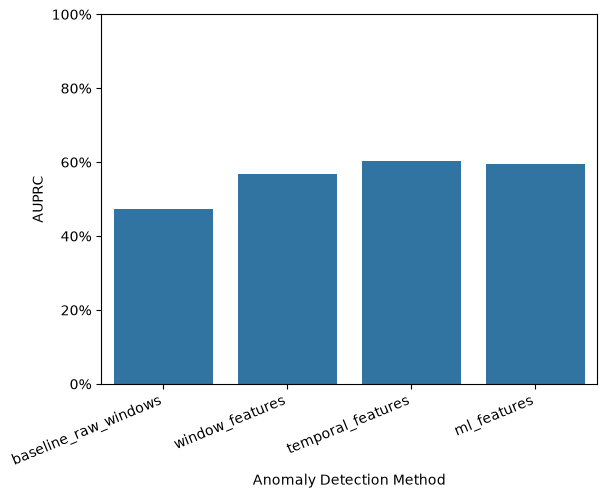

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

model_order = [
    "baseline_raw_windows",
    "window_features",
    "temporal_features",
    "ml_features"
]

best_results["model"] = pd.Categorical(
    best_results["model"],
    categories=model_order,
    ordered=True
)

best_results = best_results.sort_values("model")

sns.barplot(
    data=best_results,
    x="model",
    y="AUPRC"
)

plt.xticks(rotation=22.5, ha="right")
plt.ylabel("AUPRC")
plt.xlabel("Anomaly Detection Method")
plt.ylim(top=1)
plt.show()


### 2.1&nbsp;Hyperparameter effects into one figure per model

Number of configurations per model:
model
baseline_raw_windows    36
ml_features             36
temporal_features       36
window_features         36
Name: configuration, dtype: int64


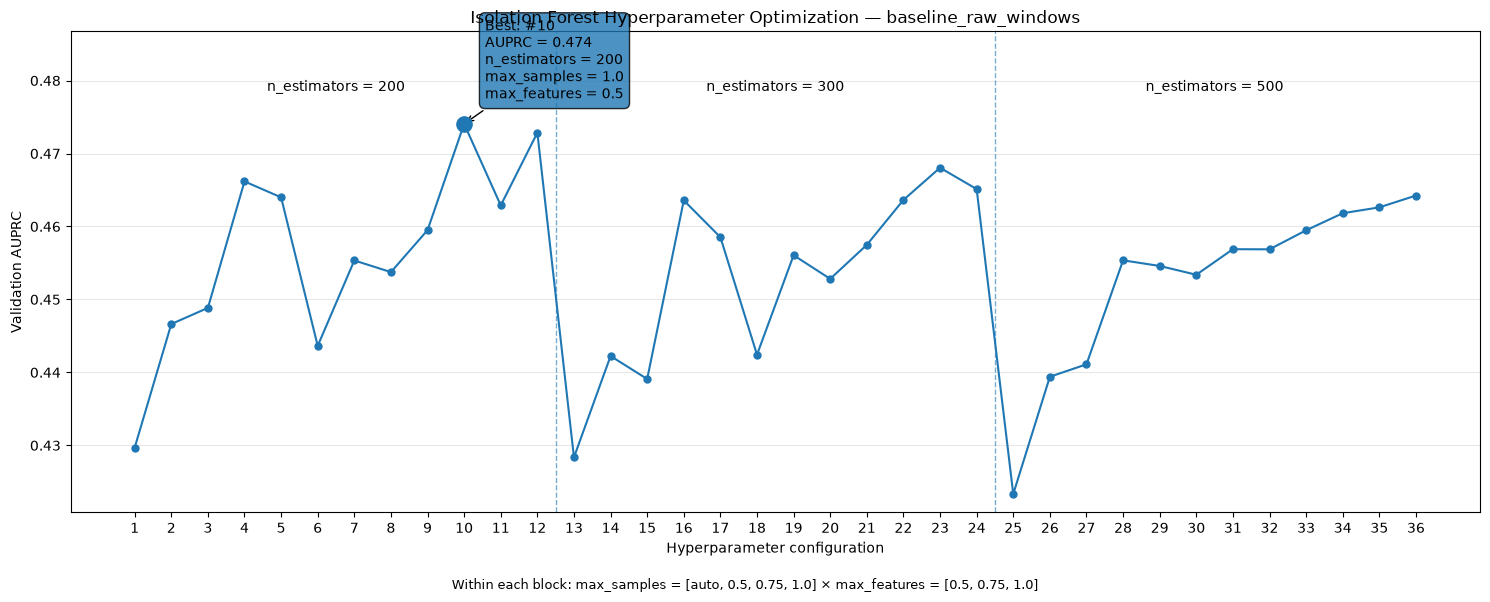

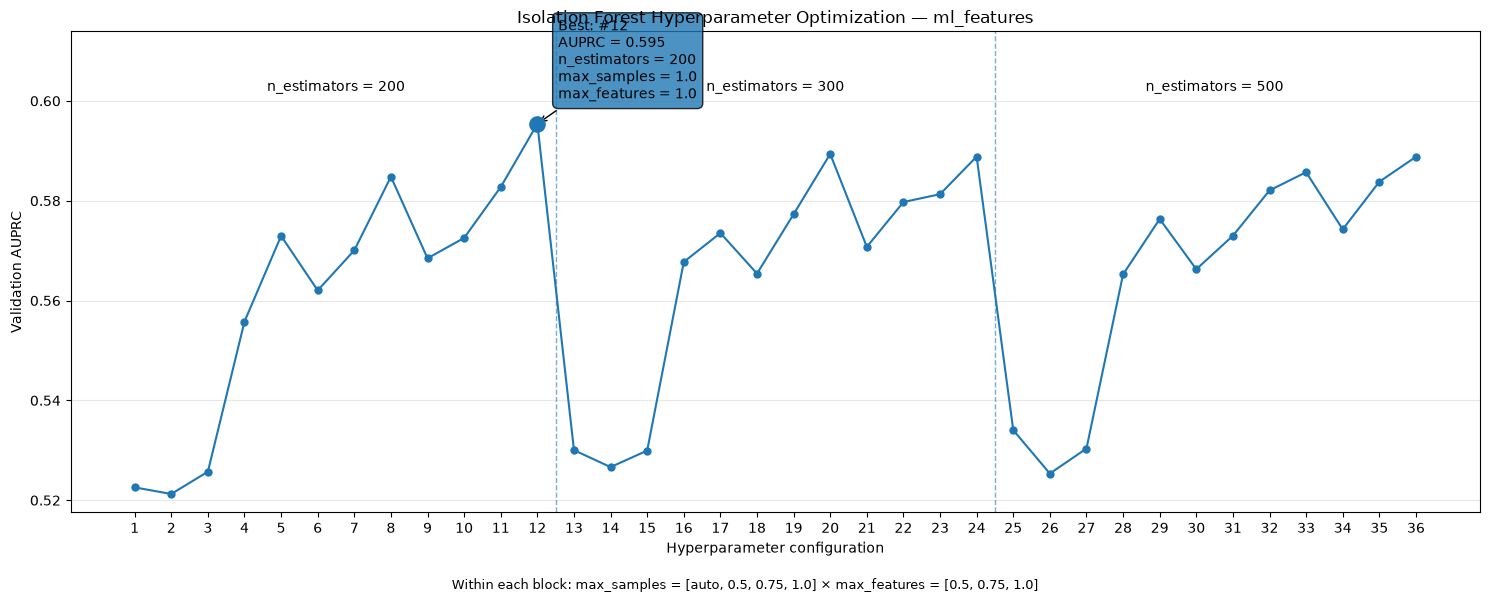

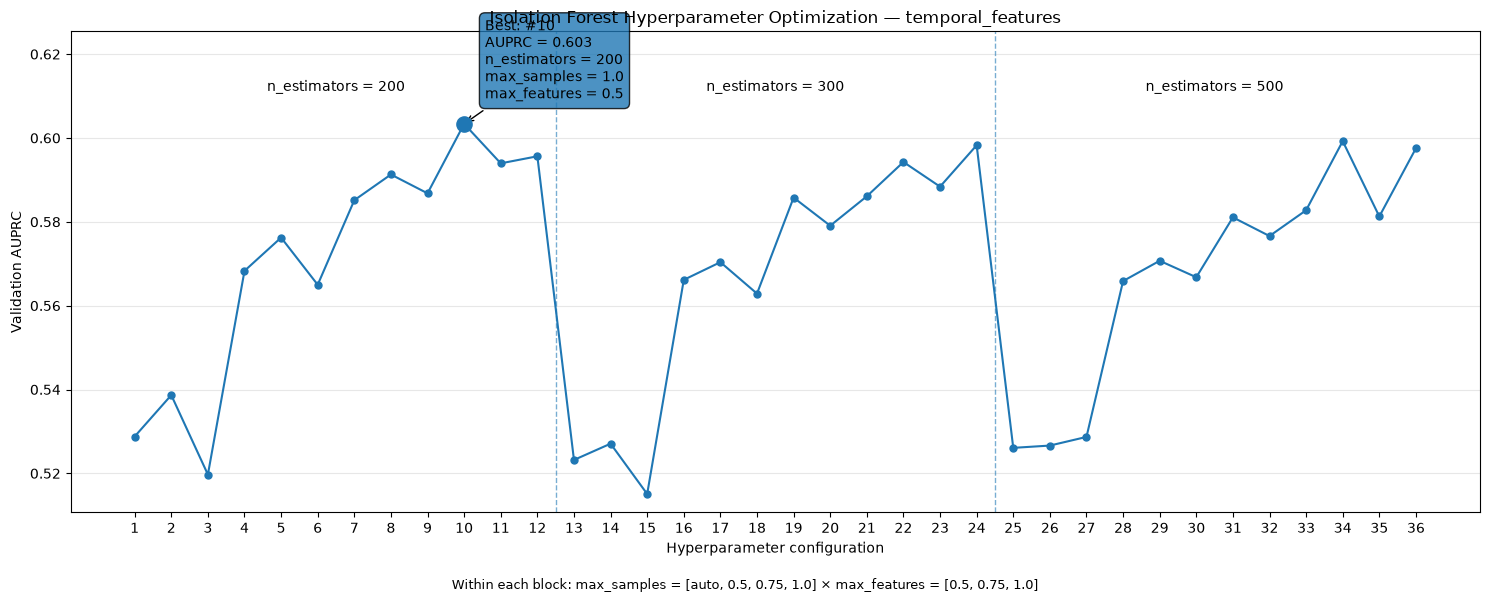

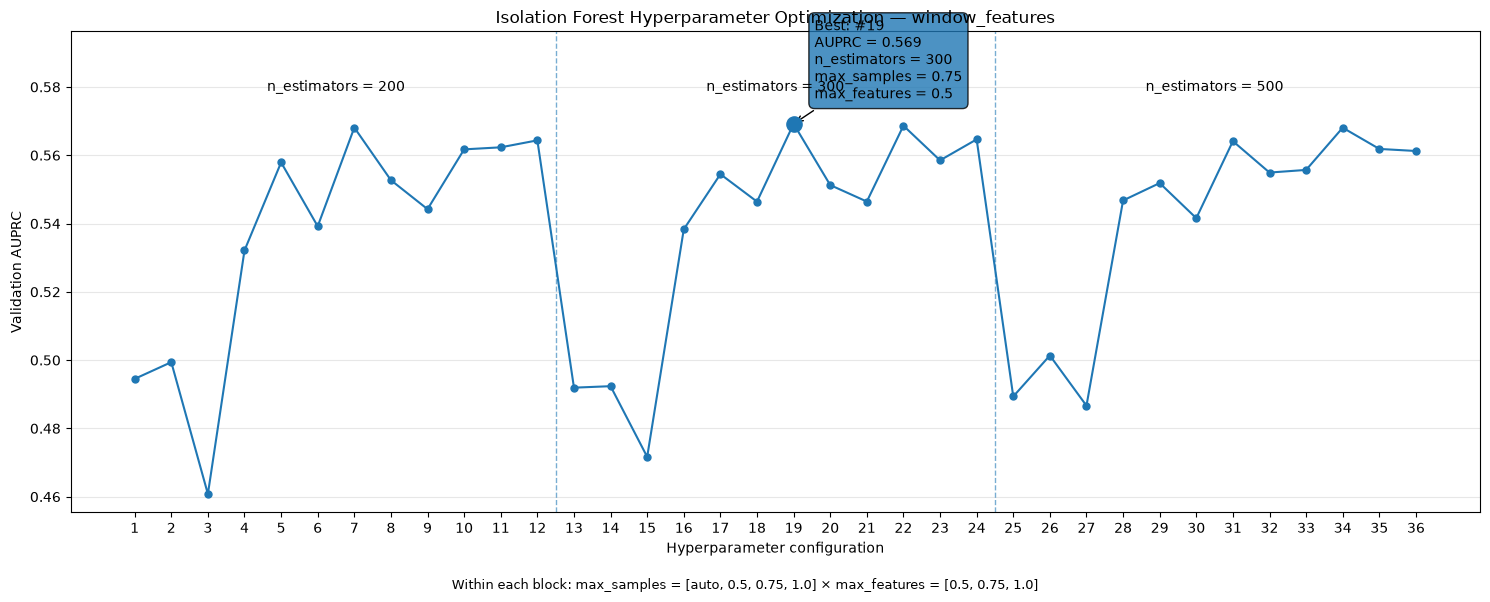

,configuration,n_estimators,max_samples,max_features,AUPRC,model
0,1,200,auto,0.50,0.429686,baseline_raw_windows
1,2,200,auto,0.75,0.446627,baseline_raw_windows
2,3,200,auto,1.00,0.448841,baseline_raw_windows
3,4,200,0.5,0.50,0.466175,baseline_raw_windows
4,5,200,0.5,0.75,0.463992,baseline_raw_windows
...,...,...,...,...,...,...
139,32,500,0.75,0.75,0.554933,window_features
140,33,500,0.75,1.00,0.555706,window_features
141,34,500,1.0,0.50,0.568070,window_features
142,35,500,1.0,0.75,0.561851,window_features


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ============================================================
# Hyperparameter Optimization — 36 Configurations per Model
# ============================================================
#
# Each point represents one complete combination of:
#   - n_estimators
#   - max_samples
#   - max_features
#
# Configurations are ordered by:
#   1. n_estimators
#   2. max_samples
#   3. max_features
#
# One figure is created for each model.
# ============================================================


# ------------------------------------------------------------
# Configuration order
# ------------------------------------------------------------

parameter_order = pd.MultiIndex.from_product(
    [
        [200, 300, 500],          # n_estimators
        ["auto", 0.5, 0.75, 1.0], # max_samples
        [0.5, 0.75, 1.0],         # max_features
    ],
    names=[
        "n_estimators",
        "max_samples",
        "max_features",
    ],
).to_frame(index=False)


# ------------------------------------------------------------
# Prepare optimization results
# ------------------------------------------------------------

plot_data = optimization_results_df.copy()

# Make max_samples consistent for matching
plot_data["max_samples_str"] = (
    plot_data["max_samples"].astype(str)
)

parameter_order["max_samples_str"] = (
    parameter_order["max_samples"].astype(str)
)


# ------------------------------------------------------------
# Add configuration number
# ------------------------------------------------------------

parameter_order["configuration"] = (
    np.arange(len(parameter_order)) + 1
)


# ------------------------------------------------------------
# Merge configuration number with results
# ------------------------------------------------------------

plot_data = plot_data.merge(
    parameter_order[
        [
            "n_estimators",
            "max_samples_str",
            "max_features",
            "configuration",
        ]
    ],
    on=[
        "n_estimators",
        "max_samples_str",
        "max_features",
    ],
    how="left",
    suffixes=("", "_order"),
)


# ------------------------------------------------------------
# Check that all 36 configurations exist for every model
# ------------------------------------------------------------

configuration_counts = (
    plot_data
    .groupby("model")["configuration"]
    .nunique()
)

print("Number of configurations per model:")
print(configuration_counts)

assert configuration_counts.eq(36).all(), (
    "At least one model does not contain all 36 configurations."
)


# ============================================================
# Create one 36-point lineplot per model
# ============================================================

for model_name in plot_data["model"].unique():

    df_model = (
        plot_data[
            plot_data["model"] == model_name
        ]
        .sort_values("configuration")
        .copy()
    )

    fig, ax = plt.subplots(figsize=(15, 6))

    # --------------------------------------------------------
    # Main line
    # --------------------------------------------------------

    ax.plot(
        df_model["configuration"],
        df_model["AUPRC"],
        marker="o",
        linewidth=1.5,
        markersize=5,
    )

    # --------------------------------------------------------
    # Identify best configuration
    # --------------------------------------------------------

    best_row = df_model.loc[
        df_model["AUPRC"].idxmax()
    ]

    best_config = int(best_row["configuration"])
    best_auprc = best_row["AUPRC"]

    # --------------------------------------------------------
    # Highlight best configuration
    # --------------------------------------------------------

    ax.scatter(
        best_config,
        best_auprc,
        s=120,
        zorder=5,
    )

    ax.annotate(
        (
            f"Best: #{best_config}\n"
            f"AUPRC = {best_auprc:.3f}\n"
            f"n_estimators = {int(best_row['n_estimators'])}\n"
            f"max_samples = {best_row['max_samples']}\n"
            f"max_features = {best_row['max_features']}"
        ),
        xy=(best_config, best_auprc),
        xytext=(15, 15),
        textcoords="offset points",
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.4",
            alpha=0.8,
        ),
        arrowprops=dict(
            arrowstyle="->",
        ),
    )

    # --------------------------------------------------------
    # Separate n_estimators blocks
    # --------------------------------------------------------

    ax.axvline(
        12.5,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.axvline(
        24.5,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    # --------------------------------------------------------
    # Block labels
    # --------------------------------------------------------

    y_min = df_model["AUPRC"].min()
    y_max = df_model["AUPRC"].max()

    y_range = y_max - y_min

    if y_range == 0:
        y_range = 0.01

    label_y = y_max + y_range * 0.08

    ax.text(
        6.5,
        label_y,
        "n_estimators = 200",
        ha="center",
        va="bottom",
    )

    ax.text(
        18.5,
        label_y,
        "n_estimators = 300",
        ha="center",
        va="bottom",
    )

    ax.text(
        30.5,
        label_y,
        "n_estimators = 500",
        ha="center",
        va="bottom",
    )

    # --------------------------------------------------------
    # X-axis
    # --------------------------------------------------------

    ax.set_xticks(
        range(1, 37)
    )

    ax.set_xlabel(
        "Hyperparameter configuration"
    )

    # --------------------------------------------------------
    # Y-axis
    # --------------------------------------------------------

    ax.set_ylabel(
        "Validation AUPRC"
    )

    # Give some space above the highest point
    ax.set_ylim(
        y_min - y_range * 0.05,
        y_max + y_range * 0.25,
    )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        f"Isolation Forest Hyperparameter Optimization — {model_name}"
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Configuration information below the plot
    # --------------------------------------------------------

    config_text = (
        "Within each block: "
        "max_samples = [auto, 0.5, 0.75, 1.0] × "
        "max_features = [0.5, 0.75, 1.0]"
    )

    fig.text(
        0.5,
        0.01,
        config_text,
        ha="center",
        fontsize=9,
    )

    plt.tight_layout(
        rect=[0, 0.04, 1, 1]
    )

    plt.show()


# ============================================================
# Optional: display the 36 configurations for verification
# ============================================================

configuration_table = (
    plot_data[
        [
            "configuration",
            "n_estimators",
            "max_samples_str",
            "max_features",
            "AUPRC",
            "model",
        ]
    ]
    .rename(
        columns={
            "max_samples_str": "max_samples"
        }
    )
    .sort_values(
        [
            "model",
            "configuration",
        ]
    )
    .reset_index(drop=True)
)

configuration_table

## 3.&nbsp;Threshold optimization on validation

In [ ]:
# ============================================================
# Threshold Optimization on Validation Data
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

N_THRESHOLDS = 1000


# ------------------------------------------------------------
# Store threshold optimization results
# ------------------------------------------------------------

threshold_results = {}
threshold_curves = {}


# ============================================================
# Optimize threshold for each model
# ============================================================

for model_name in best_models.keys():

    print("=" * 70)
    print(f"Threshold optimization: {model_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # Retrieve fitted model and preprocessing
    # --------------------------------------------------------

    model = best_models[model_name]
    imputer = best_preprocessors[model_name]
    features_used = best_features[model_name]

    # --------------------------------------------------------
    # Validation data only
    # --------------------------------------------------------

    validation_df = model_datasets[model_name]["validation"].copy()

    X_validation = validation_df[features_used]
    y_validation = validation_df["observable_anomaly"].astype(int)

    # --------------------------------------------------------
    # Apply the already-fitted training imputer
    # --------------------------------------------------------

    X_validation_imputed = imputer.transform(
        X_validation
    )

    # --------------------------------------------------------
    # Generate continuous anomaly scores
    #
    # Higher score = more anomalous
    # --------------------------------------------------------

    validation_scores = -model.score_samples(
        X_validation_imputed
    )

    # --------------------------------------------------------
    # Generate threshold candidates
    #
    # Using the observed score range ensures that the search
    # covers the actual validation score distribution.
    # --------------------------------------------------------

    thresholds = np.linspace(
        validation_scores.min(),
        validation_scores.max(),
        N_THRESHOLDS,
    )

    threshold_rows = []

    # --------------------------------------------------------
    # Evaluate every threshold
    # --------------------------------------------------------

    for threshold in thresholds:

        y_pred = (
            validation_scores >= threshold
        ).astype(int)

        precision = precision_score(
            y_validation,
            y_pred,
            zero_division=0,
        )

        recall = recall_score(
            y_validation,
            y_pred,
            zero_division=0,
        )

        f1 = f1_score(
            y_validation,
            y_pred,
            zero_division=0,
        )

        tn, fp, fn, tp = confusion_matrix(
            y_validation,
            y_pred,
            labels=[0, 1],
        ).ravel()

        threshold_rows.append(
            {
                "threshold": threshold,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
            }
        )

    threshold_df = pd.DataFrame(
        threshold_rows
    )

    # --------------------------------------------------------
    # Find threshold with maximum F1
    # --------------------------------------------------------

    best_idx = threshold_df["f1"].idxmax()

    best_threshold_row = threshold_df.loc[
        best_idx
    ]

    best_threshold = best_threshold_row["threshold"]

    # --------------------------------------------------------
    # Store complete threshold curve
    # --------------------------------------------------------

    threshold_curves[model_name] = threshold_df

    # --------------------------------------------------------
    # Store best threshold
    # --------------------------------------------------------

    threshold_results[model_name] = {
        "threshold": best_threshold,
        "precision": best_threshold_row["precision"],
        "recall": best_threshold_row["recall"],
        "f1": best_threshold_row["f1"],
        "tn": int(best_threshold_row["tn"]),
        "fp": int(best_threshold_row["fp"]),
        "fn": int(best_threshold_row["fn"]),
        "tp": int(best_threshold_row["tp"]),
    }

    print(
        f"Best threshold: {best_threshold:.6f}"
    )

    print(
        f"Precision:       {best_threshold_row['precision']:.4f}"
    )

    print(
        f"Recall:          {best_threshold_row['recall']:.4f}"
    )

    print(
        f"F1:              {best_threshold_row['f1']:.4f}"
    )

    print(
        f"TN: {int(best_threshold_row['tn'])} | "
        f"FP: {int(best_threshold_row['fp'])} | "
        f"FN: {int(best_threshold_row['fn'])} | "
        f"TP: {int(best_threshold_row['tp'])}"
    )

    print()

Threshold optimization: baseline_raw_windows
Best threshold: 0.411828
Precision:       0.3779
Recall:          0.8338
F1:              0.5201
TN: 944 | FP: 1470 | FN: 178 | TP: 893

Threshold optimization: window_features
Best threshold: 0.428194
Precision:       0.4155
Recall:          0.8683
F1:              0.5621
TN: 1106 | FP: 1308 | FN: 141 | TP: 930

Threshold optimization: temporal_features
Best threshold: 0.385237
Precision:       0.4091
Recall:          0.9038
F1:              0.5633
TN: 1016 | FP: 1398 | FN: 103 | TP: 968

Threshold optimization: ml_features
Best threshold: 0.390952
Precision:       0.4236
Recall:          0.8982
F1:              0.5757
TN: 1105 | FP: 1309 | FN: 109 | TP: 962



In [ ]:
# ============================================================
# Threshold Optimization Summary
# ============================================================

threshold_summary = pd.DataFrame(
    threshold_results
).T

threshold_summary.index.name = "model"

threshold_summary = threshold_summary[
    [
        "threshold",
        "precision",
        "recall",
        "f1",
        "tn",
        "fp",
        "fn",
        "tp",
    ]
]

threshold_summary = threshold_summary.sort_values(
    "f1",
    ascending=False,
)

threshold_summary

,threshold,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,
ml_features,0.390952,0.423602,0.898226,0.575703,1105.0,1309.0,109.0,962.0
temporal_features,0.385237,0.409129,0.903828,0.563282,1016.0,1398.0,103.0,968.0
window_features,0.428194,0.415550,0.868347,0.562103,1106.0,1308.0,141.0,930.0
baseline_raw_windows,0.411828,0.377909,0.833800,0.520093,944.0,1470.0,178.0,893.0


## 4.&nbsp;Final test evaluation

In [ ]:
# ============================================================
# Final Test Evaluation
# ============================================================
#
# IMPORTANT:
# - Models were selected/tuned using TRAIN + VALIDATION only.
# - Thresholds were selected using VALIDATION only.
# - FINAL TEST is used here exactly once for final evaluation.
# - No model, feature set, imputer, hyperparameter, or threshold
#   is changed based on final-test performance.
# ============================================================

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# ------------------------------------------------------------
# Evaluate all four frozen models
# ------------------------------------------------------------

final_test_results = {}

for model_name in best_models.keys():

    # --------------------------------------------------------
    # Frozen objects from previous steps
    # --------------------------------------------------------
    model = best_models[model_name]
    imputer = best_preprocessors[model_name]
    features_used = best_features[model_name]

    # Threshold was optimized on validation only
    threshold = threshold_results[model_name]["threshold"]

    # --------------------------------------------------------
    # Final test data
    # --------------------------------------------------------
    final_test_df = model_datasets[model_name]["final_test"].copy()

    X_final_test = final_test_df[features_used]
    y_final_test = final_test_df["observable_anomaly"].astype(int)

    # --------------------------------------------------------
    # Apply the training-fitted imputer
    # --------------------------------------------------------
    X_final_test_imputed = imputer.transform(X_final_test)

    # --------------------------------------------------------
    # Continuous anomaly score
    #
    # Isolation Forest:
    # score_samples() -> higher = more normal
    # therefore:
    # -score_samples() -> higher = more anomalous
    # --------------------------------------------------------
    final_test_scores = -model.score_samples(
        X_final_test_imputed
    )

    # --------------------------------------------------------
    # AUPRC
    #
    # Uses continuous anomaly scores.
    # The previously selected threshold is NOT involved.
    # --------------------------------------------------------
    auprc = average_precision_score(
        y_final_test,
        final_test_scores
    )

    # --------------------------------------------------------
    # Classification using the F1-optimized validation threshold
    # --------------------------------------------------------
    y_final_pred = (
        final_test_scores >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Classification metrics
    # --------------------------------------------------------
    precision = precision_score(
        y_final_test,
        y_final_pred,
        zero_division=0
    )

    recall = recall_score(
        y_final_test,
        y_final_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_final_test,
        y_final_pred,
        zero_division=0
    )

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------
    tn, fp, fn, tp = confusion_matrix(
        y_final_test,
        y_final_pred,
        labels=[0, 1]
    ).ravel()

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    final_test_results[model_name] = {
        "threshold": threshold,
        "auprc": auprc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n_test": len(final_test_df),
        "n_anomalies": int(y_final_test.sum()),
        "n_normal": int((y_final_test == 0).sum()),
    }


# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

final_test_summary = pd.DataFrame(
    final_test_results
).T

final_test_summary.index.name = "model"

final_test_summary = final_test_summary[
    [
        "threshold",
        "auprc",
        "precision",
        "recall",
        "f1",
        "tn",
        "fp",
        "fn",
        "tp",
        "n_test",
        "n_anomalies",
        "n_normal",
    ]
]

# Sort by primary metric: AUPRC
final_test_summary = final_test_summary.sort_values(
    "auprc",
    ascending=False
)

final_test_summary

,threshold,auprc,precision,recall,f1,tn,fp,fn,tp,n_test,n_anomalies,n_normal
model,,,,,,,,,,,,
temporal_features,0.385237,0.768806,0.480170,0.870719,0.618990,1539.0,1101.0,151.0,1017.0,3808.0,1168.0,2640.0
ml_features,0.390952,0.756645,0.455464,0.849315,0.592947,1454.0,1186.0,176.0,992.0,3808.0,1168.0,2640.0
window_features,0.428194,0.701654,0.471164,0.783390,0.588424,1613.0,1027.0,253.0,915.0,3808.0,1168.0,2640.0
baseline_raw_windows,0.411828,0.442672,0.348119,0.752568,0.476036,994.0,1646.0,289.0,879.0,3808.0,1168.0,2640.0


In [ ]:
print(baseline_raw_windows.columns.tolist())
print(window_features.columns.tolist())
print(temporal_features.columns.tolist())
print(ml_features.columns.tolist())

['identifier', 'batch', 'operating_point', 'experiment', 'experiment_type', 'window', 'window_start', 'window_end', 'anomaly_label', 'T701_00', 'T701_01', 'T701_02', 'T701_03', 'T701_04', 'T701_05', 'T701_06', 'T701_07', 'T701_08', 'T701_09', 'T701_10', 'T701_11', 'T701_12', 'T701_13', 'T701_14', 'T701_15', 'T701_16', 'T701_17', 'T701_18', 'T701_19', 'T701_20', 'T701_21', 'T701_22', 'T701_23', 'T701_24', 'T701_25', 'T701_26', 'T701_27', 'T701_28', 'T701_29', 'T701_30', 'T701_31', 'T701_32', 'T701_33', 'T701_34', 'T701_35', 'T701_36', 'T701_37', 'T701_38', 'T701_39', 'T701_40', 'T701_41', 'T701_42', 'T701_43', 'T701_44', 'T701_45', 'T701_46', 'T701_47', 'T701_48', 'T701_49', 'T701_50', 'T701_51', 'T701_52', 'T701_53', 'T701_54', 'T701_55', 'T701_56', 'T701_57', 'T701_58', 'T701_59', 'T702_00', 'T702_01', 'T702_02', 'T702_03', 'T702_04', 'T702_05', 'T702_06', 'T702_07', 'T702_08', 'T702_09', 'T702_10', 'T702_11', 'T702_12', 'T702_13', 'T702_14', 'T702_15', 'T702_16', 'T702_17', 'T702_18'

In [ ]:
baseline_raw_windows

# Model Development — Final Results & Decisions

## 1. Objective

The objective is to detect **observable process anomalies** in batch-distillation experiments using Isolation Forest and progressively richer representations of 60-second process windows.

The project targets **Explainable Fault Diagnosis**: beyond detecting anomalous process behavior, the final analysis should identify the process variables and process areas associated with detected anomalies.

---

## 2. ML Observation

One ML observation corresponds to **one complete 60-second Operation-phase window**.

* Startup phase excluded
* Shutdown phase excluded
* Only complete 60-second windows used
* Partial/incomplete windows excluded
* 126 unassigned windows remain excluded

The target `observable_anomaly` is derived from the original `anomaly_label`:

| Original label | Meaning for ML           | `observable_anomaly` |
| -------------: | ------------------------ | -------------------: |
|              0 | Normal                   |                    0 |
|              1 | Blind/unobservable phase |                  NaN |
|              2 | Observable anomaly       |                    1 |
|              3 | Observable anomaly       |                    1 |

Windows with `observable_anomaly = NaN` are excluded from validation and final-test evaluation.

---

## 3. Train / Validation / Final-Test Strategy

The split is performed at **experiment level**, not at individual-window level, to prevent windows from the same experiment appearing in different datasets.

| Split      |                       Experiments | Purpose                                  |
| ---------- | --------------------------------: | ---------------------------------------- |
| Train      |                Normal experiments | Fit Isolation Forest                     |
| Validation | 38 observable-anomaly experiments | Model/hyperparameter/threshold selection |
| Final test | 39 observable-anomaly experiments | Final unbiased evaluation                |

The validation and final-test sets contain 20 unique `(batch, operating_point)` groups each.

The final test set remains completely untouched during model and threshold selection.

---

## 4. Progressive Feature-Engineering Models

The four models are **nested feature representations**, not independent feature sets.

```text
Model 1: baseline_raw_windows
Raw 60-second sensor signals
        │
        ▼
Model 2: window_features
+ statistical/process features
        │
        ▼
Model 3: temporal_features
+ temporal/dynamic features
        │
        ▼
Model 4: ml_features
+ frequency-domain features
```

Feature counts:

| Model                  | Original features | Features used |
| ---------------------- | ----------------: | ------------: |
| `baseline_raw_windows` |             1,800 |         1,800 |
| `window_features`      |               240 |           240 |
| `temporal_features`    |               720 |           720 |
| `ml_features`          |               780 |           778 |

Two `ml_features` frequency features were removed because they exceeded the 95% missingness threshold:

* `dominant_power_ratio_LS701`
* `dominant_power_ratio_LS702`

---

## 5. Preprocessing

For each model:

1. Feature columns are identified independently.
2. Features with more than 95% missing values are removed based on the **training set only**.
3. Missing values are median-imputed.
4. The imputer is fitted on training data only.
5. The same fitted imputer is applied to validation and final-test data.

No information from validation or final test is used to fit preprocessing.

---

## 6. Isolation Forest

All models use Isolation Forest.

Fixed random state:

```python
RANDOM_STATE = 42
```

Initial number of estimators:

```python
N_ESTIMATORS = 300
```

Hyperparameter optimization used:

```python
PARAM_GRID = {
    "n_estimators": [200, 300, 500],
    "max_samples": ["auto", 0.5, 0.75, 1.0],
    "max_features": [0.5, 0.75, 1.0],
}
```

This produces:

**36 configurations per model × 4 models = 144 model fits.**

`contamination="auto"` was kept fixed because threshold optimization is handled separately.

---

## 7. Model Selection Metric

The primary model-selection metric is:

**Average Precision / AUPRC**

AUPRC is calculated from the continuous Isolation Forest anomaly scores.

Isolation Forest's `score_samples()` returns higher values for more normal observations, therefore the anomaly score is defined as:

```python
anomaly_score = -model.score_samples(X)
```

AUPRC does not depend on selecting one classification threshold. It evaluates the precision-recall relationship across thresholds.

Secondary metric:

**F1 score**

---

## 8. Validation Results Before Threshold Optimization

| Model                  |     AUPRC |        F1 |
| ---------------------- | --------: | --------: |
| `ml_features`          | **0.521** |     0.445 |
| `temporal_features`    |     0.506 |     0.435 |
| `window_features`      |     0.463 | **0.473** |
| `baseline_raw_windows` |     0.435 |     0.416 |

Based on the predefined primary metric (validation AUPRC), `ml_features` was selected as the best model representation.

---

## 9. Threshold Optimization

The classification threshold was optimized **after model/hyperparameter selection** using the validation set only.

The objective was to maximize F1.

Selected thresholds:

| Model                  | Validation threshold | Validation F1 |
| ---------------------- | -------------------: | ------------: |
| `ml_features`          |             0.390952 |     **0.576** |
| `temporal_features`    |             0.385237 |         0.563 |
| `window_features`      |             0.428194 |         0.562 |
| `baseline_raw_windows` |             0.411828 |         0.520 |

The selected threshold for each model is then frozen before final-test evaluation.

---

## 10. Final-Test Results

The final test set was evaluated using the frozen models, preprocessing, and validation-selected thresholds.

| Feature representation |     AUPRC | Precision |    Recall |        F1 |
| ---------------------- | --------: | --------: | --------: | --------: |
| `baseline_raw_windows` |     0.443 |     0.348 |     0.753 |     0.476 |
| `window_features`      |     0.702 |     0.471 |     0.783 |     0.588 |
| `temporal_features`    | **0.769** | **0.480** | **0.871** | **0.619** |
| `ml_features`          |     0.757 |     0.455 |     0.849 |     0.593 |

Final-test set:

* 3,808 usable windows
* 1,168 observable-anomaly windows
* 2,640 normal windows

---

## 11. Final-Test Confusion Matrices

### Temporal features

|                | Predicted Normal | Predicted Anomaly |
| -------------- | ---------------: | ----------------: |
| Actual Normal  |            1,539 |             1,101 |
| Actual Anomaly |              151 |             1,017 |

Recall:

**87.1%**

### ML features

|                | Predicted Normal | Predicted Anomaly |
| -------------- | ---------------: | ----------------: |
| Actual Normal  |            1,454 |             1,186 |
| Actual Anomaly |              176 |               992 |

Recall:

**84.9%**

---

## 12. Interpretation of Feature Engineering

The results represent a **progressive feature-engineering experiment**.

Final-test AUPRC:

```text
Raw signals                    0.443
      ↓
+ Statistical/process features 0.702
      ↓
+ Temporal/dynamic features    0.769
      ↓
+ Frequency-domain features    0.757
```

Main observations:

1. Adding statistical/process features produces a large improvement over the raw-signal baseline.
2. Adding temporal/dynamic features produces another substantial improvement.
3. Adding frequency-domain features does not provide additional performance on the final test.
4. The strongest final-test representation is `temporal_features`.
5. The difference between `temporal_features` and `ml_features` is relatively small:

   * 0.769 vs. 0.757 AUPRC.

The appropriate conclusion is **not** that frequency features are harmful. Rather:

> Frequency-domain features did not provide additional anomaly-detection value beyond the temporal representation in this experiment.

---

## 13. Formal Model-Selection Decision

The model must be selected using validation data, not final-test performance.

Therefore:

**Formally selected model: `ml_features`**

Reason:

`ml_features` achieved the highest validation AUPRC:

**0.521**

The final-test performance of the selected model is:

* AUPRC: **0.757**
* Precision: **0.455**
* Recall: **0.849**
* F1: **0.593**

`temporal_features` achieved the highest final-test performance, but it must **not** retrospectively replace `ml_features` because the final test was reserved for unbiased evaluation.

This distinction preserves the validity of the train/validation/final-test methodology.

---

## 14. PCA Decision

PCA is **not part of the current final model pipeline**.

Reason:

* PCA could reduce dimensionality.
* However, PCA transforms process variables into principal components.
* This would reduce direct interpretability of the original process variables.
* Explainability is a central project objective.

PCA may be investigated as an **optional secondary experiment**, but it must not alter the already locked final-test evaluation.

If investigated, PCA must be fitted on training data only.

---

## 15. Feature-Selection Decision

Feature selection is relevant primarily for **explainability** and potentially as a secondary modeling experiment.

The primary next question is:

> Which process variables and derived features are most responsible for the anomaly-detection behavior?

Feature selection should therefore be investigated after the main model results have been locked.

Potential approaches include:

* permutation-based feature importance
* comparison of important features in normal vs. anomalous windows
* local analysis of individual anomalous windows
* grouping important features by process area

Feature selection must not be used to retrospectively improve the final-test result.

---

## 16. Current Status

### Completed

* Data preparation
* 60-second window definition
* Observable anomaly target
* Experiment-level train/validation/final-test split
* Four nested feature representations
* Missing-value handling
* Isolation Forest baseline
* Hyperparameter optimization
* Validation-based model selection
* Validation-based threshold optimization
* Final-test evaluation
* Final model-development results locked

### Next phase

**Explainability & Validation**

Main objectives:

1. Identify globally important features.
2. Explain individual anomalous windows.
3. Map important features to physical process variables.
4. Group variables into process areas.
5. Compare explanations for true positives, false positives, and false negatives.
6. Determine whether detected anomalies correspond to meaningful process behavior.
7. Develop the final Level-3 explainable fault-diagnosis narrative.

---

## 17. Important Methodological Rule

From this point onward:

**Do not use final-test performance to select, tune, or modify the model.**

The final-test results above are considered locked.

Any additional PCA, feature-selection, explainability, or model experiments must use training/validation data unless explicitly defined as a separate exploratory analysis that does not alter the final model.
